In [11]:
# Code 1: Data Load + Basic Info
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Total Employees:", len(df))
print("Attrition Rate:", round(df['Attrition'].eq('Yes').sum()/len(df)*100,1), "%")
print("Avg Salary: $", round(df['MonthlyIncome'].mean(),0))
print("Avg Age:", round(df['Age'].mean(),1))

Total Employees: 1470
Attrition Rate: 16.1 %
Avg Salary: $ 6503.0
Avg Age: 36.9


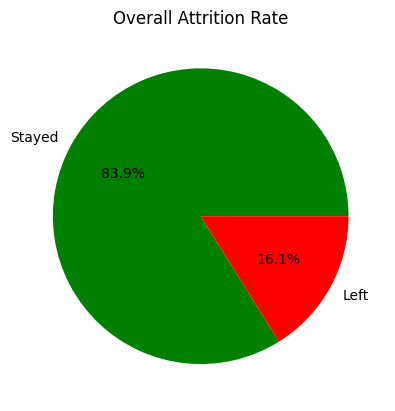

In [12]:
# Code 2: Kitne log gaye vs ruke - Pie Chart
sizes = df['Attrition'].value_counts()
plt.pie(sizes, labels=['Stayed','Left'], colors=['green','red'], autopct='%1.1f%%')
plt.title('Overall Attrition Rate')
plt.show()

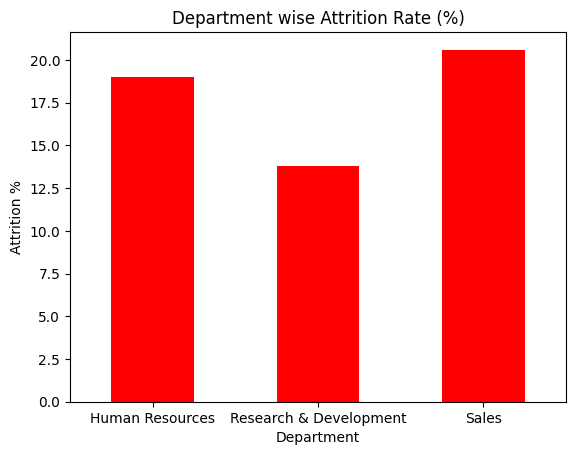

In [13]:
# Code 3: Department wise Attrition Rate
dept = df.groupby('Department')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
dept.plot(kind='bar', color='red')
plt.title('Department wise Attrition Rate (%)')
plt.xlabel('Department')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

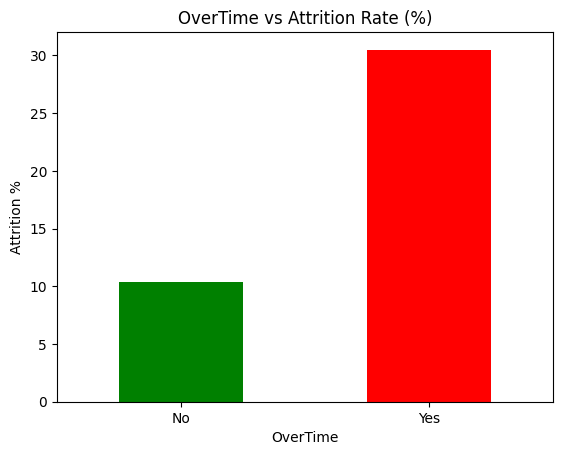

In [14]:
# Code 4: OverTime vs Attrition - Bar Chart
ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
ot.plot(kind='bar', color=['green','red'])
plt.title('OverTime vs Attrition Rate (%)')
plt.xlabel('OverTime')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

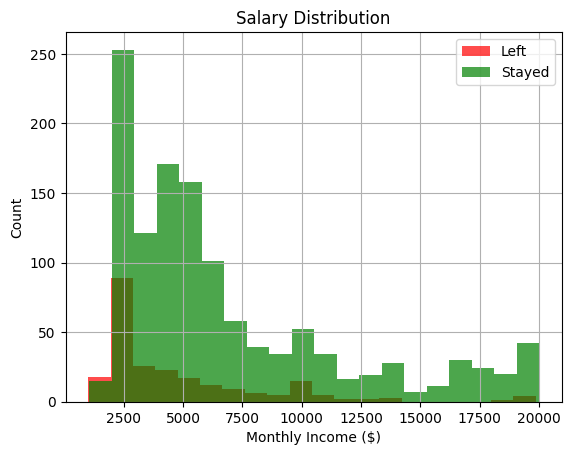

In [15]:
# Code 5: Salary - Left vs Stayed
df[df['Attrition']=='Yes']['MonthlyIncome'].hist(
    bins=20, color='red', alpha=0.7, label='Left')
df[df['Attrition']=='No']['MonthlyIncome'].hist(
    bins=20, color='green', alpha=0.7, label='Stayed')
plt.title('Salary Distribution')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Count')
plt.legend()
plt.show()

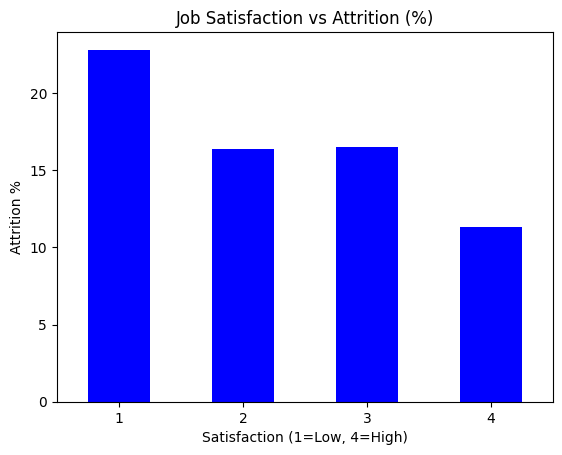

In [16]:
# Code 6: Job Satisfaction vs Attrition
jsat = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
jsat.plot(kind='bar', color='blue')
plt.title('Job Satisfaction vs Attrition (%)')
plt.xlabel('Satisfaction (1=Low, 4=High)')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

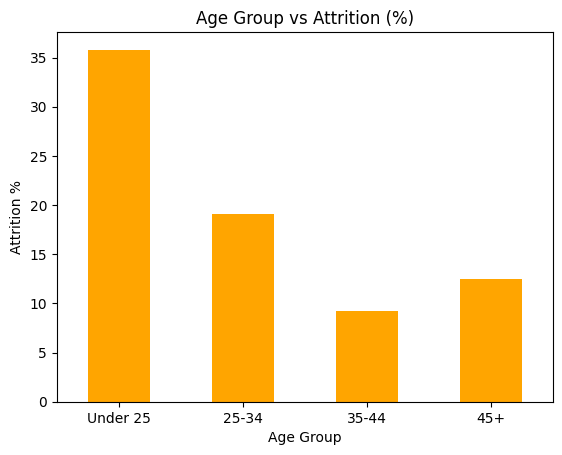

In [17]:
# Code 7: Age Group vs Attrition
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[17,25,35,45,60],
    labels=['Under 25','25-34','35-44','45+'])
age = df.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
age.plot(kind='bar', color='orange')
plt.title('Age Group vs Attrition (%)')
plt.xlabel('Age Group')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

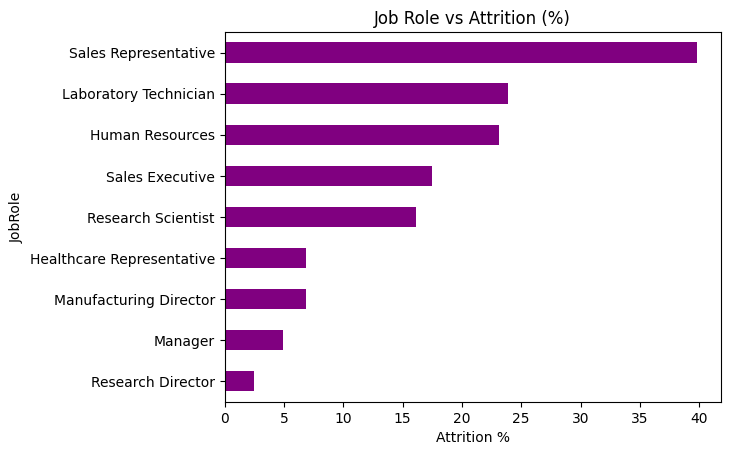

In [18]:
# Code 8: Job Role vs Attrition
role = df.groupby('JobRole')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
role.sort_values().plot(kind='barh', color='purple')
plt.title('Job Role vs Attrition (%)')
plt.xlabel('Attrition %')
plt.show()

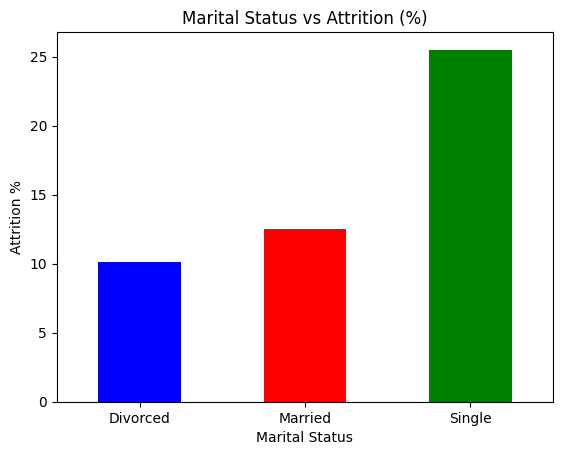

In [19]:
# Code 9: Marital Status vs Attrition
mar = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
mar.plot(kind='bar', color=['blue','red','green'])
plt.title('Marital Status vs Attrition (%)')
plt.xlabel('Marital Status')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

In [20]:
# Code 10: Final Key Insights
print("=" * 40)
print("      FINAL KEY INSIGHTS")
print("=" * 40)
print("1. Attrition Rate     :", round(df['Attrition'].eq('Yes').sum()/len(df)*100,1), "%")
print("2. Risky Department   :", dept.idxmax(), "-", dept.max(), "%")
print("3. OverTime Attrition :", ot['Yes'], "%")
print("4. Avg Salary (Left)  : $", round(df[df['Attrition']=='Yes']['MonthlyIncome'].mean(),0))
print("5. Avg Salary (Stayed): $", round(df[df['Attrition']=='No']['MonthlyIncome'].mean(),0))
print("6. Highest Risk Role  :", role.idxmax(), "-", role.max(), "%")
print("=" * 40)
print("Project Complete!")

      FINAL KEY INSIGHTS
1. Attrition Rate     : 16.1 %
2. Risky Department   : Sales - 20.6 %
3. OverTime Attrition : 30.5 %
4. Avg Salary (Left)  : $ 4787.0
5. Avg Salary (Stayed): $ 6833.0
6. Highest Risk Role  : Sales Representative - 39.8 %
Project Complete!
